C:\Users\DELL\AppData\Local\Temp\ipykernel_35796\3317763627.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='H', names=['Year', 'Mass', 'Uncertainty'])
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Dataset Loaded Successfully!
      Year    Mass  Uncertainty
0  2002.29    0.00       134.71
1  2002.35   69.38        70.85
2  2002.62 -212.95        53.55
3  2002.71 -232.60        65.24
4  2002.79 -197.91        39.23

🧠 Training the AI (this may take a moment)...
Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0299
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6587e-04
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.2278e-04
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7769e-04
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.9915e-04
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8004e-04
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8006e-04
Epoch 8/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8101e-04
Epoch 9/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6187e-04
Epoch 10/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.3406e-04
Epoch 11/50
183/183 ━━━

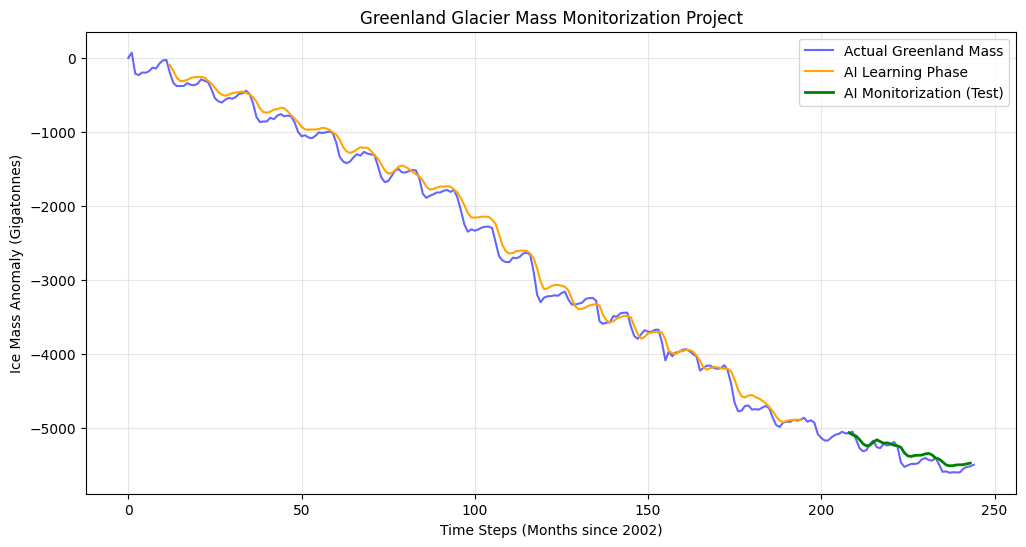

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# =========================
# 1. LOAD DATA
# =========================
filename = 'greenland_mass_200204_202505.txt'

try:
    df = pd.read_csv(filename, delim_whitespace=True, comment='H',
                     names=['Year', 'Mass', 'Uncertainty'])
    print("✅ Dataset Loaded Successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"❌ Error: File '{filename}' not found.")
    exit()

# =========================
# 2. PREPARE DATA
# =========================
data = df[['Mass']].values.astype('float32')

# Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Train-Test Split
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# =========================
# 3. CREATE DATASET
# =========================
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i+look_back, 0])
        Y.append(dataset[i+look_back, 0])
    return np.array(X), np.array(Y)

look_back = 12  # 12 months

X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

# Reshape for LSTM ✅ (IMPORTANT FIX)
X_train = X_train.reshape(X_train.shape[0], look_back, 1)
X_test = X_test.reshape(X_test.shape[0], look_back, 1)

# =========================
# 4. BUILD LSTM MODEL
# =========================
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# =========================
# 5. TRAIN MODEL
# =========================
print("\n🧠 Training the AI...")
model.fit(X_train, y_train, epochs=30, batch_size=16,
          validation_data=(X_test, y_test), verbose=1)

# =========================
# 6. PREDICTIONS
# =========================
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
actual_data = scaler.inverse_transform(scaled_data)

# =========================
# 7. EVALUATION
# =========================
train_mse = mean_squared_error(y_train_actual, train_predict)
test_mse = mean_squared_error(y_test_actual, test_predict)

print(f"\n📊 Train MSE: {train_mse}")
print(f"📊 Test MSE: {test_mse}")

# =========================
# 8. FUTURE PREDICTION (NEXT 12 MONTHS)
# =========================
future_steps = 12
future_input = scaled_data[-look_back:]
future_input = future_input.reshape(1, look_back, 1)

future_predictions = []

for _ in range(future_steps):
    next_pred = model.predict(future_input)
    future_predictions.append(next_pred[0][0])
    
    # Update input
    future_input = np.append(future_input[:, 1:, :], [[next_pred]], axis=1)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

print("\n🔮 Future Predictions (Next 12 Months):")
print(future_predictions)

# =========================
# 9. VISUALIZATION
# =========================
plt.figure(figsize=(14, 7))

# Actual Data
plt.plot(actual_data, label='Actual Data')

# Train Prediction Plot
train_plot = np.empty_like(scaled_data)
train_plot[:, :] = np.nan
train_plot[look_back:len(train_predict)+look_back, :] = train_predict
plt.plot(train_plot, label='Train Prediction')

# Test Prediction Plot
test_plot = np.empty_like(scaled_data)
test_plot[:, :] = np.nan
test_plot[len(train_predict)+(look_back):len(train_predict)+(look_back)+len(test_predict), :] = test_predict
plt.plot(test_plot, label='Test Prediction')

# Future Plot
future_plot = np.empty_like(scaled_data)
future_plot = np.append(actual_data.flatten(), future_predictions.flatten())

plt.title('Greenland Glacier Mass Monitoring (AI-Based)')
plt.xlabel('Time (Months)')
plt.ylabel('Ice Mass (Gigatonnes)')
plt.legend()
plt.grid(True)

plt.show()